In [3]:
from util import * 
import matplotlib.pyplot as plt 
from numpy import sin, pi

Corrcoef: 0.8020


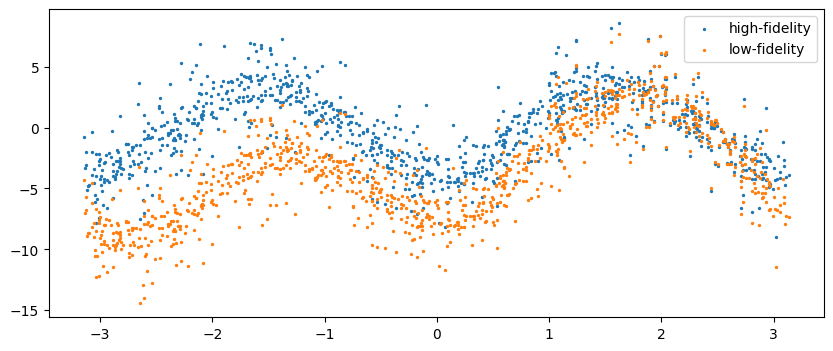

In [ ]:
# Ishigami Test Function
a,b = 7.0, 0.05
funcs = [
    lambda x: sin(x[0]) + a*sin(x[1])**2 + b*x[2]**4*sin(x[0])-3.6745685825562786, # High-fidelity 
    lambda x: funcs[0](x) + x[1]**2*sin(x[1]) -3.5555378028647846# Low-Fidelity
]

# Assigning sample sizes
N_hi, N_lo, N_test = 80, 250, 1000 
# Assigning computational budgets 
C_hi, C_lo = 1, 0.2
X_hi = np.random.uniform(-pi,pi, size=(3, N_hi))
X_lo = np.random.uniform(-pi,pi, size=(3, N_lo))
X_test = np.random.uniform(-pi,pi, size=(3,N_test))

# Centering Functions
Y_hi = funcs[0](X_hi) 
Y_lo = funcs[1](X_lo)

corr_coef = np.corrcoef(funcs[0](X_test), funcs[1](X_test))[0,1]

print("Corrcoef: %.4f" % corr_coef)

plt.figure(figsize=(10,4))
plt.scatter(X_test[1,:], funcs[0](X_test), s=2,label = "high-fidelity")
plt.scatter(X_test[1,:], funcs[1](X_test), s=2,label = "low-fidelity")
plt.legend()

In [200]:
g1 = GP(
    X_lo.T,
    Y_lo, 
    RBF, 
    Linear, 
    max_cond = 1e8,
    noise_var = 1e-7, 
    epsilon = 1e-12,
    calibrate=True
)

g1.set_params(
    {'noise_var': jnp.array(-12.55099289), 
     'k_param':   jnp.array([707.39124399,  13.55350479,   7.04909747,  17.72159056]),
     'm_param':   jnp.array([-0.04495421, -0.78224497, -4.37106633, -0.30689989])}
)

Calibrated white noise variance: 2.3061e-05


In [188]:
optimizer = ADAM(g1, neg_mll, beta1=0.95, beta2=0.999)
optimizer.run(lr=5e-1, epochs=1000, params=['k_param', 'm_param', 'noise_var'])

100%|██████████| 1000/1000 [00:04<00:00, 219.73it/s, Loss: 2.8696e+00]


{'noise_var': Array(-12.55099289, dtype=float64),
 'k_param': Array([707.39124399,  13.55350479,   7.04909747,  17.72159056], dtype=float64),
 'm_param': Array([-0.04495421, -0.78224497, -4.37106633, -0.30689989], dtype=float64)}

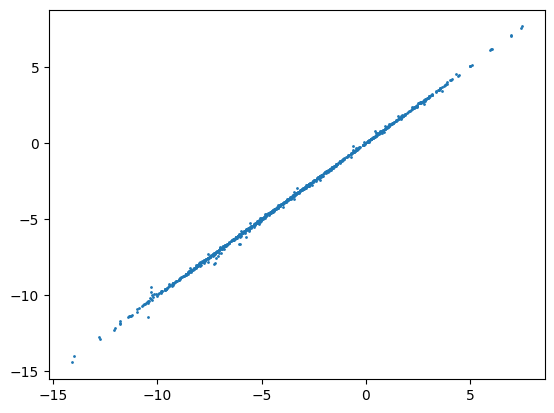

In [201]:
yhat_lo = g1.predict(X_test.T, full_cov=False)[0]
plt.scatter(yhat_lo, funcs[1](X_test), s = 1.0)

In [202]:
g0 = DeltaGP(
    X_hi.T,
    Y_hi, 
    g1.predict(X_hi.T, full_cov=False)[0], 
    RBF, 
    Zero, 
    noise_var = 1e-4, 
    epsilon = 1e-8, 
    max_cond = 1e5
)

g0.set_params(
    {'noise_var': jnp.array(-4.42980423), 
    'k_param':    jnp.array([  9.73185295, 148.63303317,   2.71150524, 280.83709397]),
    'm_param':    jnp.array([0., 0., 0.]), 
    'rho':        jnp.array(1.00197636)}
)

Calibrated white noise variance: 1.4087e-03


In [191]:
optimizer = ADAM(g0, delta_neg_mll, beta1=0.95, beta2=0.999)
optimizer.run(lr=5e-1, epochs=1000, params=['rho', 'k_param', 'm_param'])

100%|██████████| 1000/1000 [00:05<00:00, 198.07it/s, Loss: -1.6518e+02]


{'noise_var': Array(-4.42980423, dtype=float64, weak_type=True),
 'k_param': Array([ 12.81483564, 216.17933515,   2.76172073, 375.7117432 ], dtype=float64),
 'm_param': Array([0., 0., 0.], dtype=float64),
 'rho': Array(1.00307107, dtype=float64, weak_type=True)}

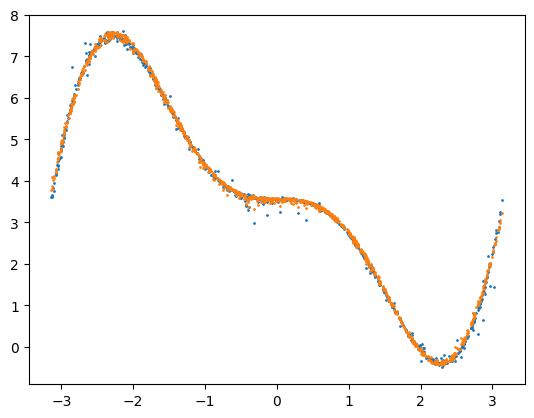

In [203]:
delta_mean = g0.predict(X_test.T, full_cov=False)[0]
yhat_hi = g0.p['rho'] * g1.predict(X_test.T, full_cov=False)[0] + delta_mean
plt.scatter(X_test[1,:], funcs[0](X_test) - g1.predict(X_test.T, full_cov=False)[0], s = 1.0)
plt.scatter(X_test[1,:], delta_mean, s = 1.0)

In [193]:
kr = GP(
    X_hi.T,
    funcs[0](X_hi), 
    RBF, 
    Linear, 
    noise_var = 1e-8, 
    epsilon = 1e-12, 
    max_cond = 1e8
)
# kr.set_params(
#     {'noise_var':jnp.array(-13.46455067),
#     'k_param':   jnp.array([ 8.77047402, -2.59487462]),
#     'm_param':   jnp.array([-1.13692191,  5.07544546])}
# ) 
optimizer = ADAM(kr, neg_mll, beta1 = 0.9, beta2 = 0.999)
optimizer.run(lr = 1e-1, epochs = 5000, params = ['k_param', 'm_param'])

Calibrated white noise variance: 1.1637e-05


100%|██████████| 5000/5000 [00:19<00:00, 257.43it/s, Loss: 6.3727e+01]


{'noise_var': Array(-11.36131249, dtype=float64),
 'k_param': Array([18.99196017,  7.98807639,  3.29008757,  6.82882193], dtype=float64),
 'm_param': Array([ 0.25813619,  0.30448013,  0.00692124, -0.4148795 ], dtype=float64)}

In [204]:
delta_mean, delta_var = g0.predict(X_test.T, full_cov = False)
lo_mean, lo_var = g1.predict(X_test.T, full_cov = False)
rho = g0.p['rho']

mean = rho * lo_mean + delta_mean 
var = rho**2 * lo_var + delta_var 
conf = 2 * np.sqrt(var)

kr_mean, kr_var = kr.predict(X_test.T, full_cov = False)
kr_conf = 2 * np.sqrt(kr_var)
print("Multifidelity: %.4e" % np.mean(var + (mean - funcs[0](X_test))**2))
print("Kriging:       %.4e" % np.mean(var + (kr_mean - funcs[0](X_test))**2))

Multifidelity: 2.8613e-02
Kriging:       1.0697e-01


80
70
60
50
40
30
20
10
0
180
170
160
150
140
130
120
110
100
90
80
70
60
50
40
30
20
10
0
380
370
360
350
340
330
320
310
300
290
280
270
260
250
240
230
220
210
200
190
180
170
160
150
140
130
120
110
100
90
80
70
60
50
40
30
20
10
0
780
770
760
750
740
730
720
710
700
690
680
670
660
650
640
630
620
610
600
590
580
570
560
550
540
530
520
510
500
490
480
470
460
450
440
430
420
410
400
390
380
370
360
350
340
330
320
310
300
290
280
270
260
250
240
230
220
210
200
190
180
170
160
150
140
130
120
110
100
90
80
70
60
50
40
30
20
10
0


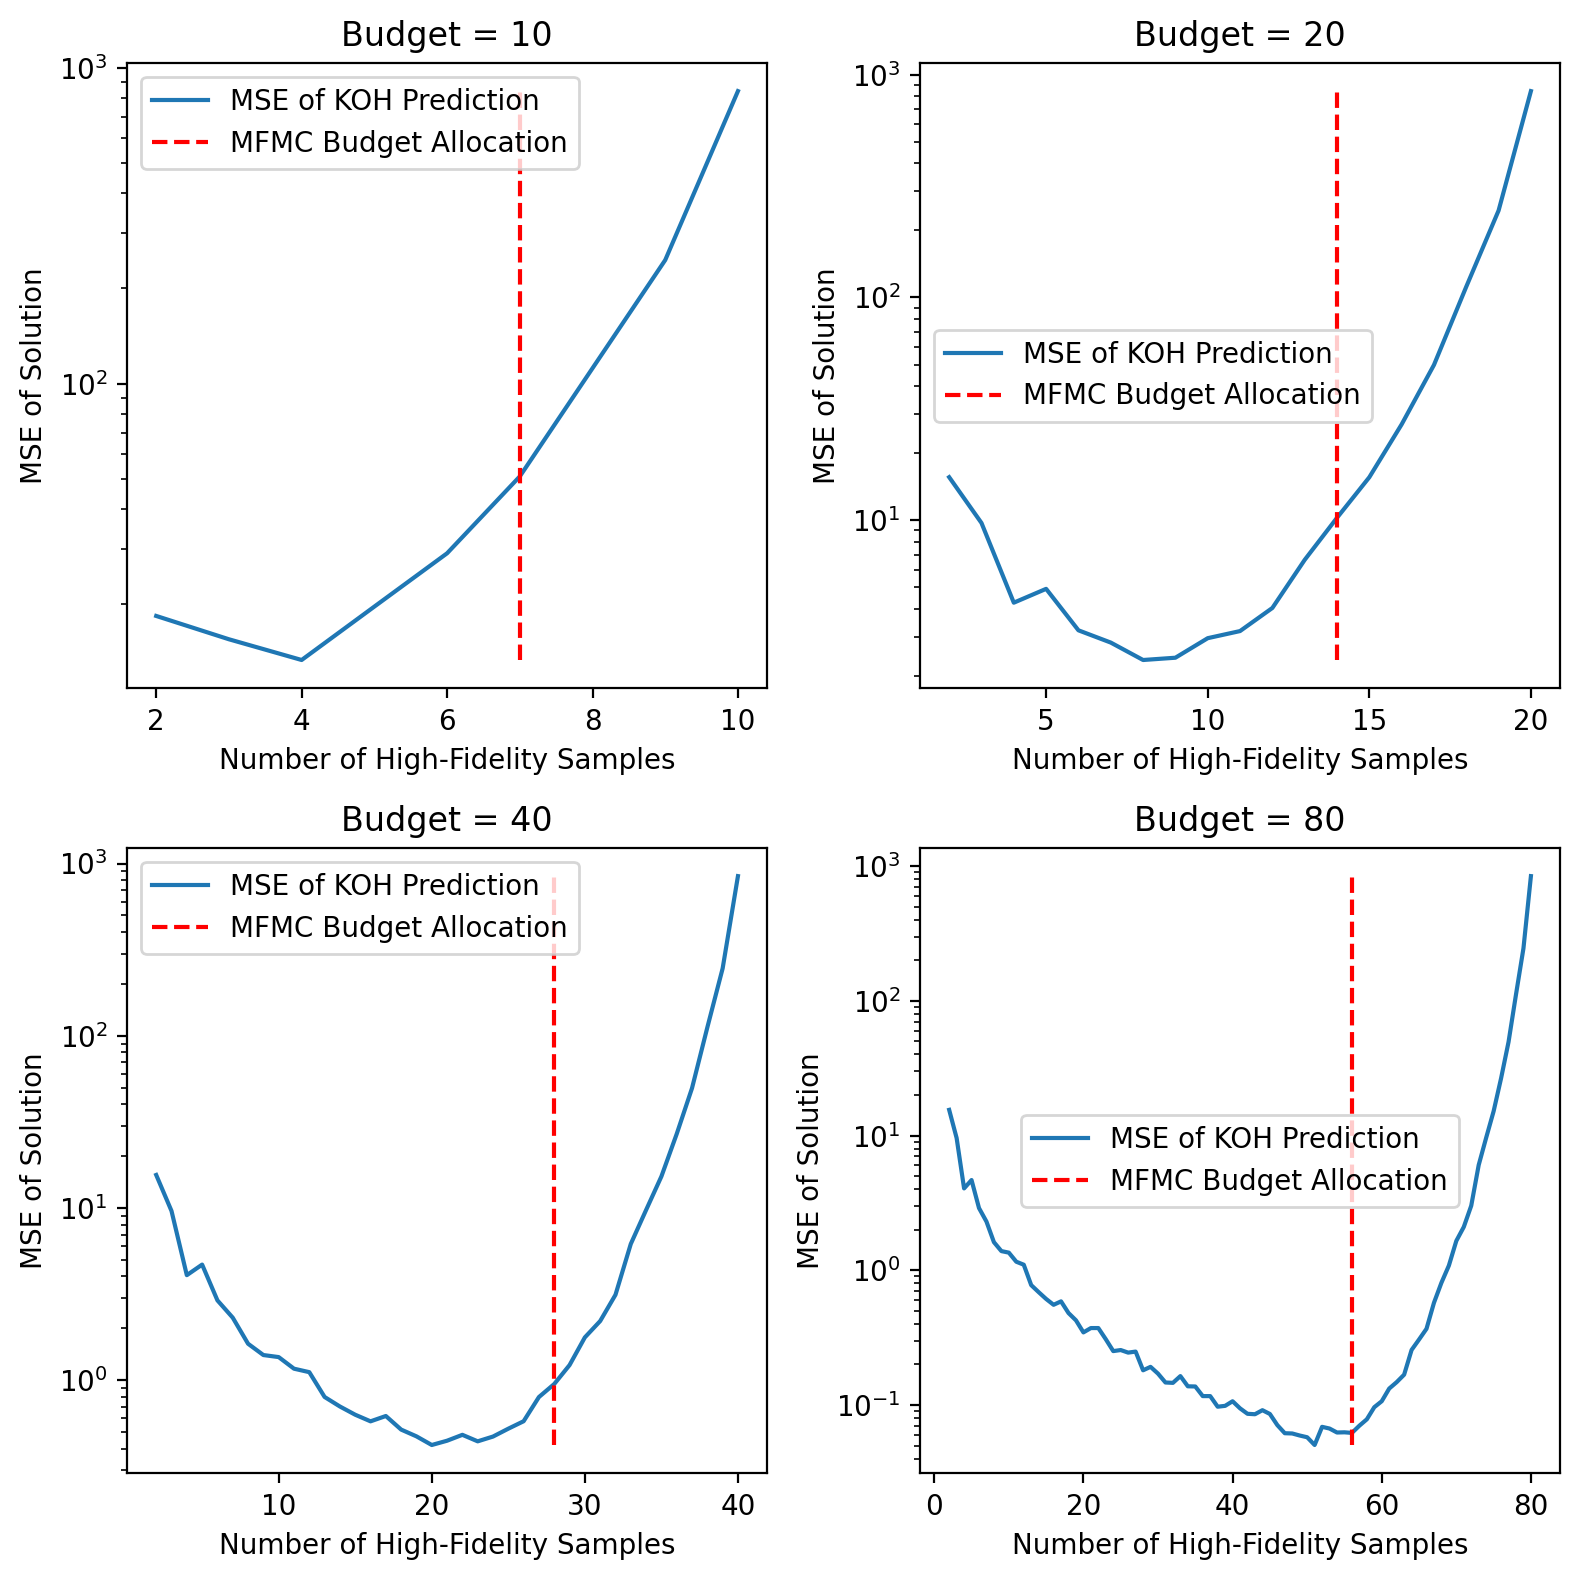

In [207]:
def get_mse(key, g0, g1, N_hi, N_lo, X_test):
    # Generating random samples 
    key_hi, key_lo = jax.random.split(key, 2)
    X_hi = jax.random.uniform(key_hi, minval=-pi, maxval=pi, shape=(3, N_hi))
    X_lo = jax.random.uniform(key_lo, minval=-pi, maxval=pi, shape=(3, N_lo))

    # Setting training data 
    g0.X, g0.Y1, g0.Y2 = X_hi.T, funcs[0](np.array(jax.device_get(X_hi))), funcs[1](np.array(jax.device_get(X_hi)))
    g0.set_params(g0.p)

    g1.X, g1.Y = X_lo.T, funcs[1](X_lo)
    g1.set_params(g1.p)

    # Making predictions
    delta_mean, delta_var = g0.predict(X_test.T, full_cov = False)
    lo_mean, lo_var = g1.predict(X_test.T, full_cov = False)
    rho = g0.p['rho']

    # Computing posterior mean and variance 
    mean = rho * lo_mean + delta_mean 
    var = rho**2 * lo_var + delta_var 

    # Returning Mean squared error of predictions 
    return jnp.mean(var + (mean - funcs[0](X_test))**2)

def avg_mse(N_hi, budget, g0, g1, N_mc, C_hi, C_lo, X_test): 
    # Number of low-fidelity samples 
    N_lo = int((budget - N_hi * C_hi) / C_lo)
    print(N_lo)

    key = jax.random.key(42)
    rng_keys = jax.random.split(key, N_mc)

    mses = np.zeros(N_mc)

    for i, key in enumerate(rng_keys):
        mses[i] = get_mse(key, g0, g1, N_hi, N_lo, X_test)

    return [jnp.mean(mses), 2*jnp.std(mses)]

budgets = [10, 20, 40, 80]
N_mc = 10
plt.figure(figsize=(8,8), dpi = 200)

# MFMC Budget Allocation for two levels of fidelity
c11, c22, c12 = np.var(funcs[0](X_test)), np.var(funcs[1](X_test)), np.cov(np.vstack((funcs[0](X_test).reshape(1,-1), funcs[1](X_test).reshape(1,-1))))[0,1]
alpha = c12 / c22 
ratio = np.sqrt(C_hi  / C_lo * corr_coef**2 / (1 - corr_coef**2))

for plot_num, budget in enumerate(budgets):

    N_hi_min, N_hi_max = 2, int(budget / C_hi)

    N_his = jnp.arange(N_hi_min, N_hi_max+1)

    N_hi_opt = budget / (C_lo * ratio + C_hi)
    N_lo_opt = ratio * N_hi_opt 

    results = jnp.array([
        avg_mse(int(N_hi), budget, g0, g1, N_mc, C_hi, C_lo, X_test)
        for N_hi in N_his
    ])
    plt.subplot(2,2,plot_num+1)
    plt.semilogy(N_his, results[:,0], label = "MSE of KOH Prediction")
    # plt.fill_between(N_his, results[:,0] - results[:,1], results[:,0] + results[:,1], alpha = 0.3, color = 'blue', label = 'two-sigma')
    plt.plot([np.round(N_hi_opt), np.round(N_hi_opt)], [min(results[:,0]), max(results[:,0])], label = "MFMC Budget Allocation", color = 'red', linestyle = 'dashed')
    plt.xlabel("Number of High-Fidelity Samples")
    plt.ylabel("MSE of Solution")
    plt.legend()
    plt.title("Budget = %d" % budget)

plt.tight_layout()

In [ ]:
N_hi_opt = budget / (C_lo * ratio + C_hi)
N_lo_opt = ratio * N_hi_opt 
N_hi_opt, N_lo_opt

(12.816808667243848, 35.91595666378077)

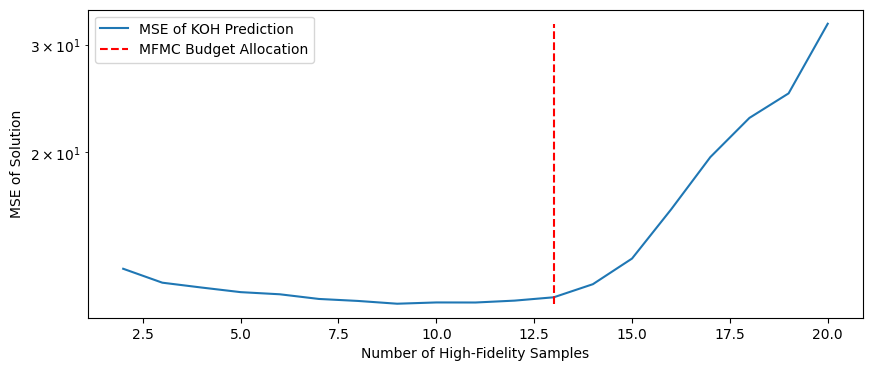

In [173]:
plt.figure(figsize=(10,4))
plt.semilogy(N_his, results[:,0], label = "MSE of KOH Prediction")
# plt.fill_between(N_his, results[:,0] - results[:,1], results[:,0] + results[:,1], alpha = 0.3, color = 'blue', label = 'two-sigma')
plt.plot([np.round(N_hi_opt), np.round(N_hi_opt)], [min(results[:,0]), max(results[:,0])], label = "MFMC Budget Allocation", color = 'red', linestyle = 'dashed')
plt.xlabel("Number of High-Fidelity Samples")
plt.ylabel("MSE of Solution")
plt.legend()
